<a href="https://colab.research.google.com/github/PALAK7890/cardiac_arrest_model/blob/main/Cardiac_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [66]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 5000

data = {
    "age": np.random.randint(18, 90, n),
    "gender": np.random.choice(["Male", "Female", "Other"], n),
    "bmi": np.random.normal(27, 5, n),
    "blood_pressure": np.random.normal(130, 20, n),
    "cholesterol": np.random.normal(200, 40, n),
    "heart_rate": np.random.normal(85, 15, n),
    "oxygen_level": np.random.normal(92, 5, n),
    "diabetes": np.random.choice(["Yes", "No"], n),
    "smoking": np.random.choice(["Yes", "No"], n),
    "exercise_level": np.random.choice(["Low", "Medium", "High"], n),
    "previous_heart_disease": np.random.choice(["Yes", "No"], n),
    "time_to_treatment": np.random.normal(30, 15, n),  # minutes
    "hospital_quality": np.random.choice(["Low", "Medium", "High"], n)
}

df = pd.DataFrame(data)

# 🎯 TARGET (realistic noisy logic)
score = (
    -0.03 * df["age"] +
    -0.02 * df["bmi"] +
    -0.02 * df["blood_pressure"] +
    -0.03 * df["cholesterol"] +
    0.05 * df["oxygen_level"] +
    -0.04 * df["time_to_treatment"]
)

# Add condition effects
score += np.where(df["diabetes"] == "Yes", -2, 1)
score += np.where(df["smoking"] == "Yes", -2, 1)
score += np.where(df["exercise_level"] == "High", 2, -1)
score += np.where(df["hospital_quality"] == "High", 3, -1)

# Add noise
score += np.random.normal(0, 5, n)

# Convert to probability
prob = 1 / (1 + np.exp(-score))

df["survived"] = (prob > 0.5).astype(int)

# 🔥 MAKE IT MESSY
df.loc[np.random.choice(n, 200), "bmi"] = None
df.loc[np.random.choice(n, 150), "cholesterol"] = "unknown"
df.loc[np.random.choice(n, 100), "gender"] = None

# Duplicate rows
df = pd.concat([df, df.sample(200)])

df.to_csv("cardiac_arrest_raw.csv", index=False)

/tmp/ipykernel_13518/2242623815.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'unknown' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[np.random.choice(n, 150), "cholesterol"] = "unknown"


In [67]:
df = pd.read_csv("cardiac_arrest_raw.csv")

# Fix wrong types
df["cholesterol"] = pd.to_numeric(df["cholesterol"], errors='coerce')

# Fill missing
df["bmi"] = df["bmi"].fillna(df["bmi"].mean())
df["cholesterol"] = df["cholesterol"].fillna(df["cholesterol"].mean())
df["gender"] = df["gender"].fillna("Unknown")

# Remove duplicates
df = df.drop_duplicates()

# Feature engineering
df["risk_score"] = (
    df["blood_pressure"] +
    df["cholesterol"] +
    df["heart_rate"]
) / 3


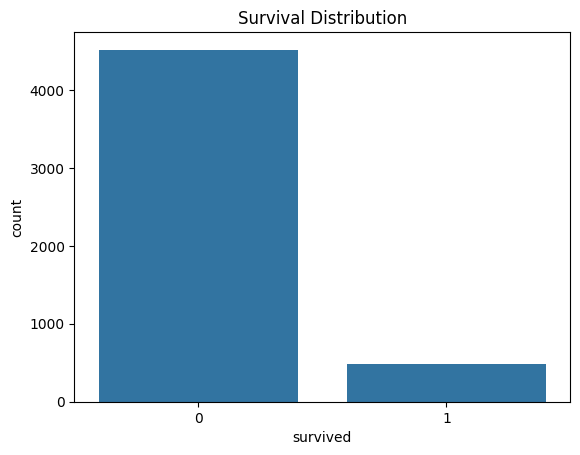

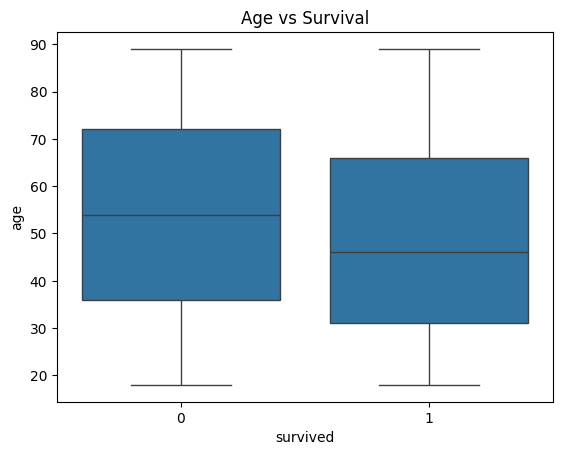

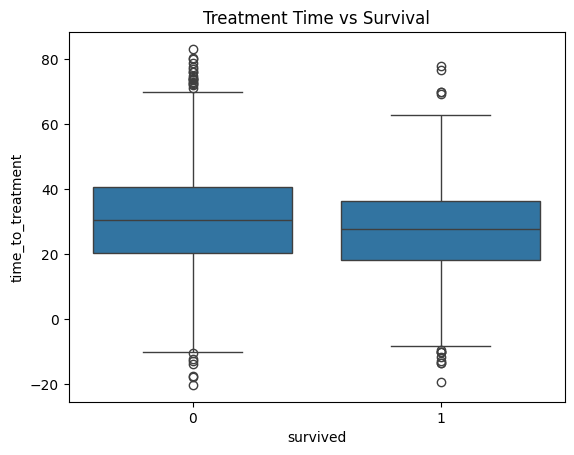

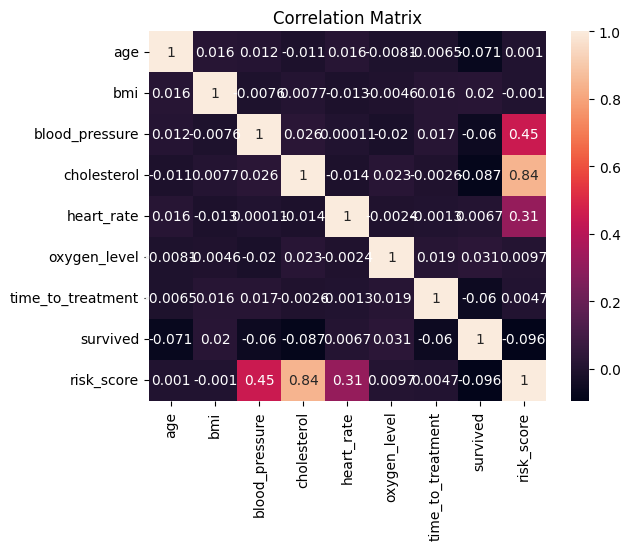

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

# Survival distribution
sns.countplot(x='survived', data=df)
plt.title("Survival Distribution")
plt.show()

# Age vs survival
sns.boxplot(x='survived', y='age', data=df)
plt.title("Age vs Survival")
plt.show()

# Time to treatment impact
sns.boxplot(x='survived', y='time_to_treatment', data=df)
plt.title("Treatment Time vs Survival")
plt.show()

# Correlation
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()



In [69]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Encode categorical
for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col])

X = df.drop("survived", axis=1)
y = df["survived"]

# Scale
X = StandardScaler().fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [74]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.Input(shape=(X.shape[1],)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)
from sklearn.utils import class_weight

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {0: weights[0], 1: weights[1]}

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights
)

Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6728 - loss: 0.6246 - precision: 0.1846 - recall: 0.6990 - val_accuracy: 0.6712 - val_loss: 0.6178 - val_precision: 0.1771 - val_recall: 0.6623
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7031 - loss: 0.5619 - precision: 0.2057 - recall: 0.7249 - val_accuracy: 0.6450 - val_loss: 0.6067 - val_precision: 0.1815 - val_recall: 0.7662
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7056 - loss: 0.5519 - precision: 0.2136 - recall: 0.7638 - val_accuracy: 0.6538 - val_loss: 0.5891 - val_precision: 0.1753 - val_recall: 0.7013
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7084 - loss: 0.5326 - precision: 0.2143 - recall: 0.7573 - val_accuracy: 0.6488 - val_loss: 0.6153 - val_precision: 0.1792 - val_recall: 0.7403
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7138 - loss: 0.5306 - precision: 0.2171 - recall: 0.7540 - val_accuracy: 0.6575 - val_loss: 0.

In [75]:
from sklearn.metrics import accuracy_score, classification_report

pred = (model.predict(X_test) > 0.3).astype(int)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 0.635
              precision    recall  f1-score   support

           0       0.96      0.62      0.75       901
           1       0.18      0.79      0.30        99

    accuracy                           0.64      1000
   macro avg       0.57      0.70      0.53      1000
weighted avg       0.89      0.64      0.71      1000

